# 极坐标

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine.data import mpg

In [2]:
mpg.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


## Simple Pie Chart


In [3]:
data = {
    "Scale": [
        ">300,000 tons per year",
        "100,000~300,000 tons per year",
        "<100,000 tons per year",
    ],
    "Proportion": ["0.2623", "0.2459", "0.4918"],
}

df = pd.DataFrame(data)
df.head()

,Scale,Proportion
0,">300,000 tons per year",0.2623
1,"100,000~300,000 tons per year",0.2459
2,"<100,000 tons per year",0.4918


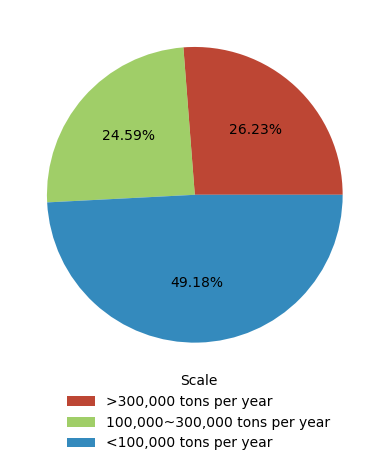

In [4]:
plt.pie(df.Proportion, colors=["#bd4634", "#7fbd34bd", "#348ABD"], autopct="%.2f%%")

plt.legend(
    df.Scale, title="Scale", bbox_to_anchor=(0.5, -0.45, 0.4, 0.5), frameon=False
)

## Pie Chart with Convex


[Text(0.5, 1.0, 'Class of Vehicles: Pie Chart')]

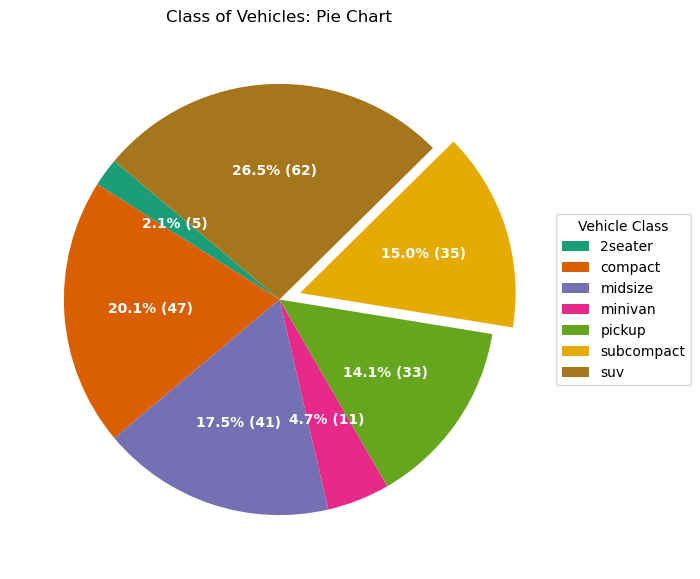

In [5]:
mpg_group = mpg.groupby("class").size().reset_index(name="counts")  # ty:ignore[no-matching-overload]

_, ax = plt.subplots(figsize=(12, 7), subplot_kw={"aspect": "equal"})

data = mpg_group["counts"]
categories = mpg_group["class"]
explode = [0, 0, 0, 0, 0, 0.1, 0]


def func(pct, allvals) -> str:
    absolute = int(pct / 100.0 * np.sum(allvals))
    return f"{pct:.1f}% ({absolute})"


wedges, texts, autotexts = ax.pie(  # ty:ignore[invalid-assignment]
    data,
    autopct=lambda pct: func(pct, data),
    textprops={"color": "w"},
    colors=plt.cm.Dark2.colors,  # ty:ignore[unresolved-attribute]
    startangle=140,
    explode=explode,
)

ax.legend(
    wedges,
    categories,
    title="Vehicle Class",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
)
plt.setp(autotexts, size=10, weight=700)
ax.set(title="Class of Vehicles: Pie Chart")


## Pie Chart with Wedges


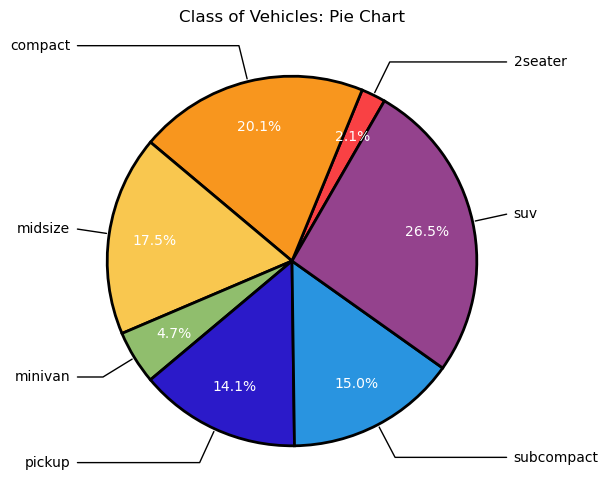

In [6]:
colors = ["#f94144", "#f8961e", "#f9c74f", "#90be6d", "#2b1ac9", "#2994e0", "#94428d"]
wedgeprops = {
    "edgecolor": "k",
    "linewidth": 2,
    "linestyle": "solid",
    "antialiased": True,
}

categories = mpg_group["class"]
data = mpg_group["counts"]

_, ax = plt.subplots(figsize=(6, 6), subplot_kw={"aspect": "equal"})

wedges, texts, autotexts = ax.pie(  # ty:ignore[invalid-assignment]
    data,
    colors=colors,
    autopct="%1.1f%%",
    startangle=60,
    pctdistance=0.75,
    wedgeprops=wedgeprops,
    textprops={"fontsize": 10, "color": "white"},
)

ax.set(title="Class of Vehicles: Pie Chart")
bbox_props = {"boxstyle": "square, pad=0.3", "fc": "w", "ec": "w", "lw": 0.5}

kw = {
    "arrowprops": {"arrowstyle": "-"},
    "bbox": bbox_props,
    "zorder": 0,
    "va": "center",
}

for k, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1) / 2.0 + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle, angleA=0, angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(
        categories[k],
        xy=(x, y),
        xytext=(1.2 * np.sign(x), 1.2 * y),
        horizontalalignment=horizontalalignment,
        **kw,  # ty:ignore[invalid-argument-type]
    )


## Polar Bar Chart


In [7]:
rng = np.random.default_rng(123)

data = pd.DataFrame(
    {
        "name": [f"item {i}" for i in range(1, 51)],
        "value": rng.integers(low=30, high=100, size=50),
        "group": ["A"] * 10 + ["B"] * 20 + ["C"] * 12 + ["D"] * 8,
    }
)

data.head()

,name,value,group
0,item 1,31,A
1,item 2,77,A
2,item 3,71,A
3,item 4,33,A
4,item 5,93,A


In [8]:
data_sorted = (
    data.groupby(["group"])
    .apply(lambda x: x.sort_values(["value"], ascending=False), include_groups=False)
    .reset_index(drop=True)
)

data_sorted.head()

,name,value
0,item 5,93
1,item 2,77
2,item 3,71
3,item 9,53
4,item 7,47


In [9]:
from typing import Any, Literal


def get_label_rotation(angle, offset) -> tuple[Any, Literal["right", "left"]]:
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else:
        alignment = "left"
    return rotation, alignment

In [10]:
def add_labels(ax, angles, values, labels, offset) -> None:
    # This is the space between the end of the bar and the label
    padding = 4

    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label in zip(angles, values, labels, strict=True):
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)

        ax.text(
            x=angle,
            y=value + padding,
            s=label,
            ha=alignment,
            va="center",
            rotation=rotation,
            rotation_mode="anchor",
        )

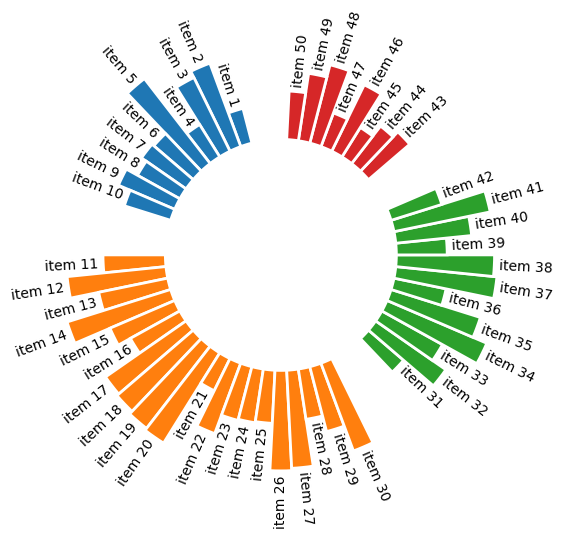

In [11]:
OFFSET = np.pi / 2

GROUP = data["group"].array
VALUES = data["value"].array
LABELS = data["name"].array

# Add three empty bars to the end of each group
PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

# Obtaining the right indexes is now a little more complicated
offset = 0
IDXS = []
GROUPS_SIZE = [10, 20, 12, 8]
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD

_, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": "polar"})

ax.set(ylim=(-100, 100), xticks=[], yticks=[], theta_offset=OFFSET, frame_on=False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)


GROUPS_SIZE = [10, 20, 12, 8]
COLORS = [f"C{i}" for i, size in enumerate(GROUPS_SIZE) for _ in range(size)]

ax.bar(ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, edgecolor="white", linewidth=2)

add_labels(ax, ANGLES[IDXS], VALUES, LABELS, OFFSET)

## Polar Scatter Chart


[None, None]

<Figure size 1000x800 with 0 Axes>

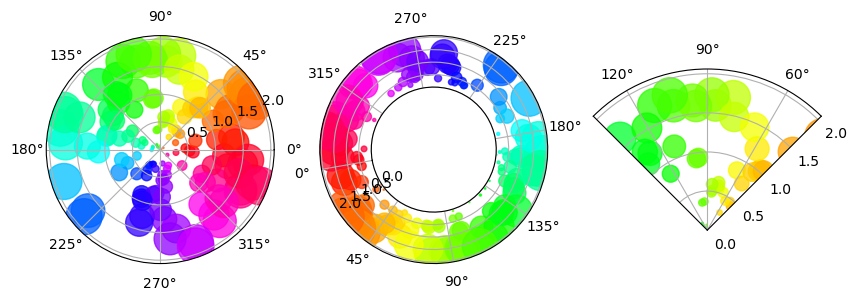

In [12]:
n_point = 150

rng = np.random.default_rng(123)

r = 2 * rng.random(n_point)
theta = 2 * np.pi * rng.random(n_point)

area = 200 * r**2  # area of each circle representing each data point
colors = theta
cmap = "hsv"
alpha = 0.75

plt.figure(figsize=(10, 8))

_, axes = plt.subplots(1, 3, figsize=(10, 6), subplot_kw={"projection": "polar"})

axes[0].scatter(theta, r, c=colors, s=area, cmap=cmap, alpha=alpha)

axes[1].scatter(theta, r, c=colors, s=area, cmap=cmap, alpha=alpha)
axes[1].set(rorigin=-2.5)
axes[1].set_theta_zero_location("W", offset=10)

axes[2].scatter(theta, r, c=colors, s=area, cmap=cmap, alpha=alpha)
axes[2].set(thetamin=45, thetamax=135)


## Dotnut


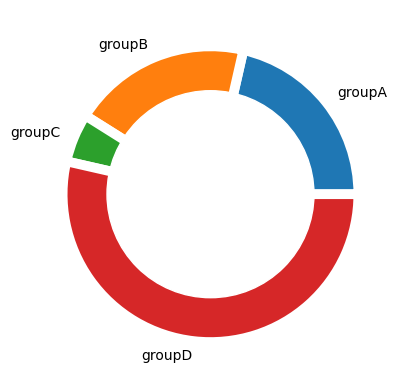

In [13]:
names = ["groupA", "groupB", "groupC", "groupD"]
size = [12, 11, 3, 30]

plt.pie(size, labels=names, wedgeprops={"linewidth": 7, "edgecolor": "white"})

my_circle = plt.Circle((0, 0), 0.7, color="white")
p = plt.gca().add_artist(my_circle)


## Radar


In [14]:
data = pd.DataFrame(
    {
        "group": ["A", "B", "C", "D"],
        "var1": [38, 1.5, 30, 4],
        "var2": [29, 10, 9, 34],
        "var3": [8, 39, 23, 24],
        "var4": [7, 31, 33, 14],
        "var5": [28, 15, 32, 14],
    }
)

data.head()

,group,var1,var2,var3,var4,var5
0,A,38.0,29,8,7,28
1,B,1.5,10,39,31,15
2,C,30.0,9,23,33,32
3,D,4.0,34,24,14,14


In [15]:
data.loc[0].drop("group").array

<NumpyExtensionArray>
[np.float64(38.0), np.int64(29), np.int64(8), np.int64(7), np.int64(28)]
Length: 5, dtype: object

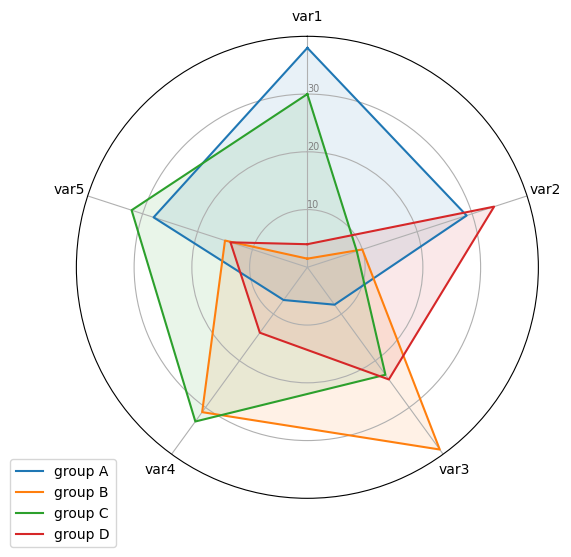

In [16]:
# number of variable
categories = data.columns[1:]
N = len(categories)

angles = [n / N * 2 * np.pi for n in range(N)]
angles += angles[:1]

_, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": "polar"})

ax.set(
    theta_offset=np.pi / 2,
    theta_direction=-1,
    rlabel_position=0,
    ylim=(0, 40),
    xticks=angles[:-1],
    xticklabels=categories,
    yticks=[10, 20, 30],
)

plt.setp(ax.get_yticklabels(), color="grey", size=7)

for ind, cat in enumerate(data.group):
    values = data.loc[ind].drop("group").array.tolist()
    values += values[:1]
    ax.plot(angles, values, label=f"group {cat}")
    ax.fill(angles, values, alpha=0.1)

ax.legend(bbox_to_anchor=(0.1, 0.1))
